In [1]:
!mkdir -p data
!wget https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv -O data/telco_churn.csv

--2026-08-31 12:19:39--  https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 970457 (948K) [text/plain]
Saving to: ‘data/telco_churn.csv’

data/telco_churn.cs 100%[===================>] 947.71K  --.-KB/s    in 0.008s  

2026-08-31 12:19:39 (116 MB/s) - ‘data/telco_churn.csv’ saved [970457/970457]



In [2]:
!ls data/

telco_churn.csv


In [3]:
import pandas as pd
df = pd.read_csv("data/telco_churn.csv")

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
# ===== SETUP =====
!pip install imbalanced-learn xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, f1_score
import xgboost as xgb
import shap

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [7]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [8]:
df['TotalCharges'].notnull().sum()

np.int64(7043)

In [9]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [10]:
df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()]["TotalCharges"]

,TotalCharges
488,
753,
936,
1082,
1340,
3331,
3826,
4380,
5218,
6670,


In [11]:
# ===== 2.1 — Load the raw CSV =====
df = pd.read_csv("data/telco_churn.csv")
print("Shape:", df.shape)

# ===== 2.2 — Check column data types =====
print("\n--- dtypes ---")
print(df.dtypes)

# ===== 2.3 — Find the exact bad values (don't guess) =====
print("\n--- Bad TotalCharges values (raw) ---")
bad_values = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()]["TotalCharges"].apply(repr)
print(bad_values)

# ===== 2.4 — Confirm WHY those rows are broken =====
print("\n--- Context for those bad rows ---")
bad_rows = df[pd.to_numeric(df["TotalCharges"], errors="coerce").isnull()]
print(bad_rows[["tenure", "MonthlyCharges", "TotalCharges"]])

# ===== 2.5 — Now fix it (justified, not guessed) =====
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan).astype(float)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# ===== 2.6 — Verify the fix =====
print("\n--- dtypes after fix ---")
print(df.dtypes)
print("\n--- describe() after fix ---")
print(df.describe())

# ===== 2.7 — Prep the target column and drop the ID =====
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df.drop(columns=["customerID"], inplace=True)
print("\n--- Final check ---")
print("Churn rate:", df["Churn"].mean().round(3))
print("Columns remaining:", df.columns.tolist())

Shape: (7043, 21)

--- dtypes ---
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

--- Bad TotalCharges values (raw) ---
488     ' '
753     ' '
936     ' '
1082    ' '
1340    ' '
3331    ' '
3826    ' '
4380    ' '
5218    ' '
6670    ' '
6754    ' '
Name: TotalCharges, dtype: object

--- Context for those bad rows ---
      tenure  MonthlyCharges TotalCharges
488        0           52.55             
753        0           20.25           

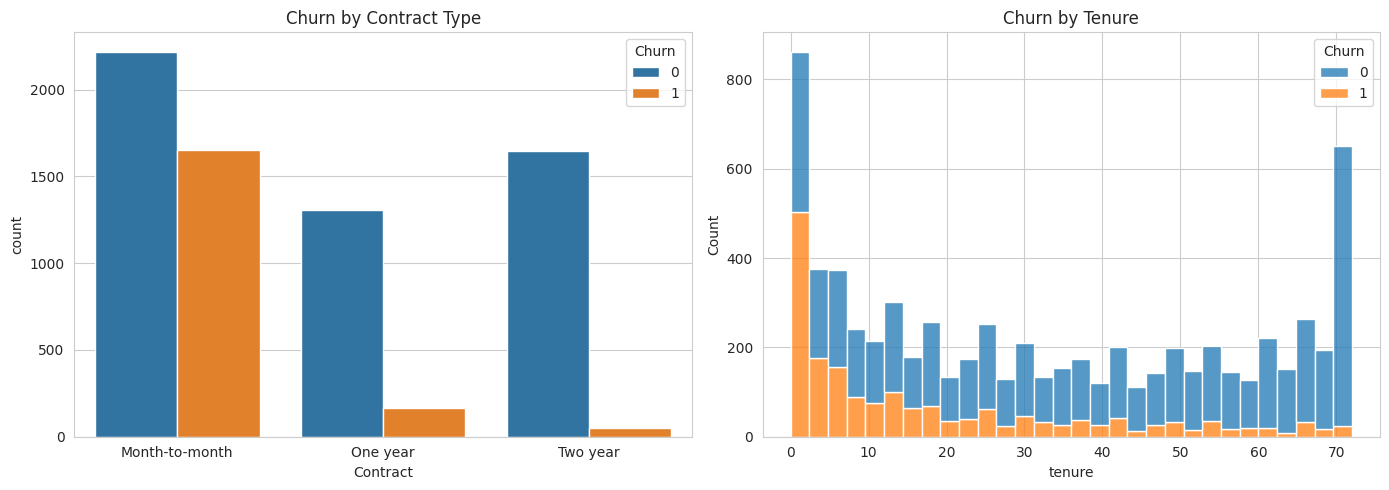

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0])
axes[0].set_title("Churn by Contract Type")

sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", ax=axes[1], bins=30)
axes[1].set_title("Churn by Tenure")

plt.tight_layout()
plt.show()

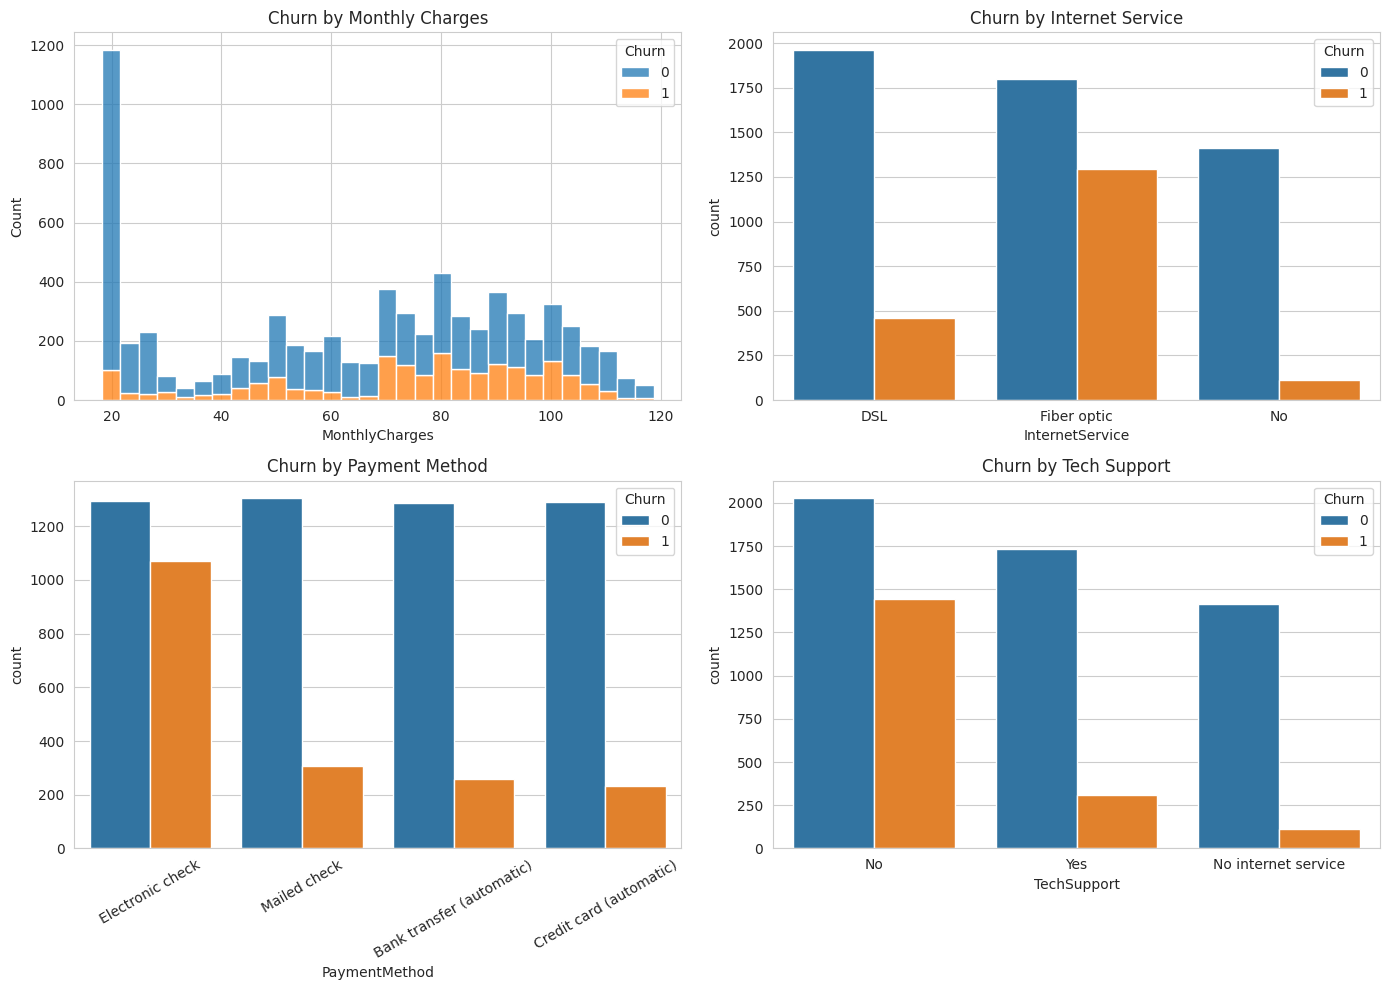

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df, x="MonthlyCharges", hue="Churn", multiple="stack", ax=axes[0,0], bins=30)
axes[0,0].set_title("Churn by Monthly Charges")

sns.countplot(data=df, x="InternetService", hue="Churn", ax=axes[0,1])
axes[0,1].set_title("Churn by Internet Service")

sns.countplot(data=df, x="PaymentMethod", hue="Churn", ax=axes[1,0])
axes[1,0].set_title("Churn by Payment Method")
axes[1,0].tick_params(axis='x', rotation=30)

sns.countplot(data=df, x="TechSupport", hue="Churn", ax=axes[1,1])
axes[1,1].set_title("Churn by Tech Support")

plt.tight_layout()
plt.show()

In [14]:
print(df.groupby("TechSupport")["Churn"].mean().round(3))
print(df.groupby("InternetService")["Churn"].mean().round(3))

TechSupport
No                     0.416
No internet service    0.074
Yes                    0.152
Name: Churn, dtype: float64
InternetService
DSL            0.190
Fiber optic    0.419
No             0.074
Name: Churn, dtype: float64


In [15]:
pd.crosstab(df["InternetService"], df["TechSupport"])

TechSupport,No,No internet service,Yes
InternetService,,,
DSL,1243,0,1178
Fiber optic,2230,0,866
No,0,1526,0


In [16]:
# 4.1 — Check unique value counts to confirm binary vs multi-category
print(df.nunique())

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [17]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [18]:
# Binary columns -> map to 0/1
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})

df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

# Multi-category columns -> one-hot encode
multi_cat_cols = ["MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
                   "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
                   "Contract", "PaymentMethod"]
df_encoded = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

print("Original shape:", df.shape)
print("Encoded shape:", df_encoded.shape)
print(df_encoded.columns.tolist())

Original shape: (7043, 20)
Encoded shape: (7043, 31)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [19]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 👇 ADD IT RIGHT HERE — after split, before scaling 👇
corr_matrix = X_train.corr().abs()
high_corr = corr_matrix.unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr < 1.0) & (high_corr > 0.7)]
print(high_corr)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

MultipleLines_No phone service        PhoneService                            1.000000
PhoneService                          MultipleLines_No phone service          1.000000
tenure                                TotalCharges                            0.829698
TotalCharges                          tenure                                  0.829698
InternetService_Fiber optic           MonthlyCharges                          0.787616
MonthlyCharges                        InternetService_Fiber optic             0.787616
                                      OnlineSecurity_No internet service      0.761983
                                      InternetService_No                      0.761983
                                      StreamingMovies_No internet service     0.761983
                                      DeviceProtection_No internet service    0.761983
StreamingTV_No internet service       MonthlyCharges                          0.761983
DeviceProtection_No internet service  Month

In [20]:
X_train.corr()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
gender,1.000000,0.007095,-0.005150,0.008329,-0.003024,0.003666,-0.025967,-0.022118,-0.008960,-0.003666,...,-0.022769,0.012565,-0.017640,0.012565,-0.022375,0.015011,-0.015234,-0.004271,-0.008924,0.012981
SeniorCitizen,0.007095,1.000000,0.015729,-0.213300,0.016980,0.008483,0.157326,0.220376,0.102318,-0.008483,...,-0.062554,-0.182473,0.113969,-0.182473,0.116375,-0.043220,-0.118882,-0.030463,0.175119,-0.151017
Partner,-0.005150,0.015729,1.000000,0.446276,0.373689,0.023485,-0.014067,0.101317,0.315081,-0.023485,...,0.120410,0.002559,0.126930,0.002559,0.119297,0.077695,0.250483,0.074696,-0.080449,-0.100625
Dependents,0.008329,-0.213300,0.446276,1.000000,0.154892,-0.004428,-0.116574,-0.114901,0.059160,0.004428,...,0.061048,0.143665,-0.018176,0.143665,-0.044152,0.059670,0.205906,0.057130,-0.150011,0.055251
tenure,-0.003024,0.016980,0.373689,0.154892,1.000000,0.003653,0.010525,0.256700,0.829698,-0.003653,...,0.326924,-0.048323,0.280643,-0.048323,0.293297,0.207860,0.554682,0.232600,-0.207599,-0.237056
PhoneService,0.003666,0.008483,0.023485,-0.004428,0.003653,1.000000,0.005433,0.248911,0.112040,-1.000000,...,-0.099676,0.173935,-0.022298,0.173935,-0.040662,-0.005288,0.001164,-0.009602,-0.000474,-0.001987
PaperlessBilling,-0.025967,0.157326,-0.014067,-0.116574,0.010525,0.005433,1.000000,0.348994,0.159013,-0.005433,...,0.033374,-0.320305,0.236077,-0.320305,0.214209,-0.059148,-0.137125,-0.025618,0.207953,-0.202434
MonthlyCharges,-0.022118,0.220376,0.101317,-0.114901,0.256700,0.248911,0.348994,1.000000,0.654117,-0.248911,...,0.339695,-0.761983,0.631545,-0.761983,0.625106,0.009658,-0.075965,0.030274,0.268826,-0.381064
TotalCharges,-0.008960,0.102318,0.315081,0.059160,0.829698,0.112040,0.159013,0.654117,1.000000,-0.112040,...,0.431296,-0.377645,0.513493,-0.377645,0.519996,0.177575,0.349803,0.182320,-0.064196,-0.297925
MultipleLines_No phone service,-0.003666,-0.008483,-0.023485,0.004428,-0.003653,-1.000000,-0.005433,-0.248911,-0.112040,1.000000,...,0.099676,-0.173935,0.022298,-0.173935,0.040662,0.005288,-0.001164,0.009602,0.000474,0.001987


In [21]:
# Check 1: Any NaN values in the features?
print("NaNs in X_train:", X_train.isnull().sum().sum())
print("NaNs in X_test:", X_test.isnull().sum().sum())

# Check 2: Any infinite values?
import numpy as np
print("Infs in X_train:", np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum())

# Check 3: What are the actual column dtypes?
print(X_train.dtypes.value_counts())

# Check 4: Any column with zero variance (all same value)?
print(X_train.nunique().sort_values().head(10))

NaNs in X_train: 0
NaNs in X_test: 0
Infs in X_train: 0
bool       21
int64       7
float64     2
Name: count, dtype: int64
gender                                2
SeniorCitizen                         2
Partner                               2
Dependents                            2
PhoneService                          2
PaperlessBilling                      2
MultipleLines_Yes                     2
MultipleLines_No phone service        2
OnlineSecurity_Yes                    2
OnlineSecurity_No internet service    2
dtype: int64


In [22]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 4))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8414


In [23]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced",
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.54      0.74      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

ROC-AUC: 0.8422


In [24]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "max_depth": 4,
    "eta": 0.1,
    "scale_pos_weight": scale_pos_weight,
    "seed": 42
}

xgb_model = xgb.train(
    params, dtrain, num_boost_round=300,
    evals=[(dtest, "test")], early_stopping_rounds=20, verbose_eval=False
)

y_proba_xgb = xgb_model.predict(dtest)
y_pred_xgb = (y_proba_xgb > 0.5).astype(int)

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_xgb), 4))

              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.8439


                 Model  ROC-AUC  F1 Score
0  Logistic Regression   0.8414    0.6164
1        Random Forest   0.8422    0.6250
2              XGBoost   0.8439    0.6250


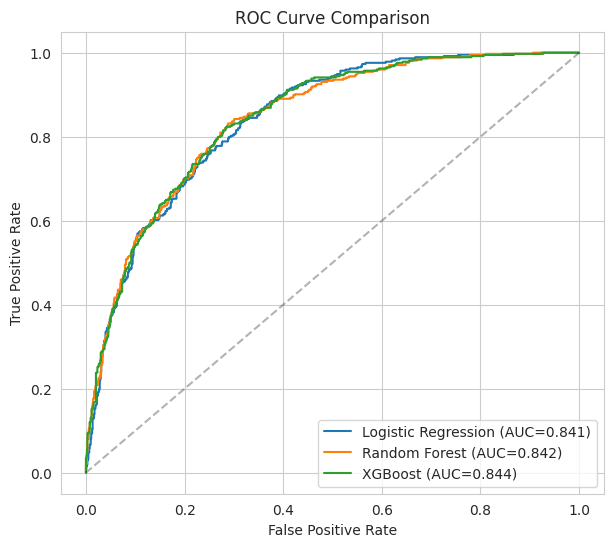

In [25]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_xgb)],
    "F1 Score": [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_xgb)]
}).round(4)
print(results)

plt.figure(figsize=(7,6))
for name, proba in [("Logistic Regression", y_proba_lr), ("Random Forest", y_proba_rf), ("XGBoost", y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")

plt.plot([0,1],[0,1],"k--", alpha=0.3)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

/tmp/ipykernel_953/3044808262.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


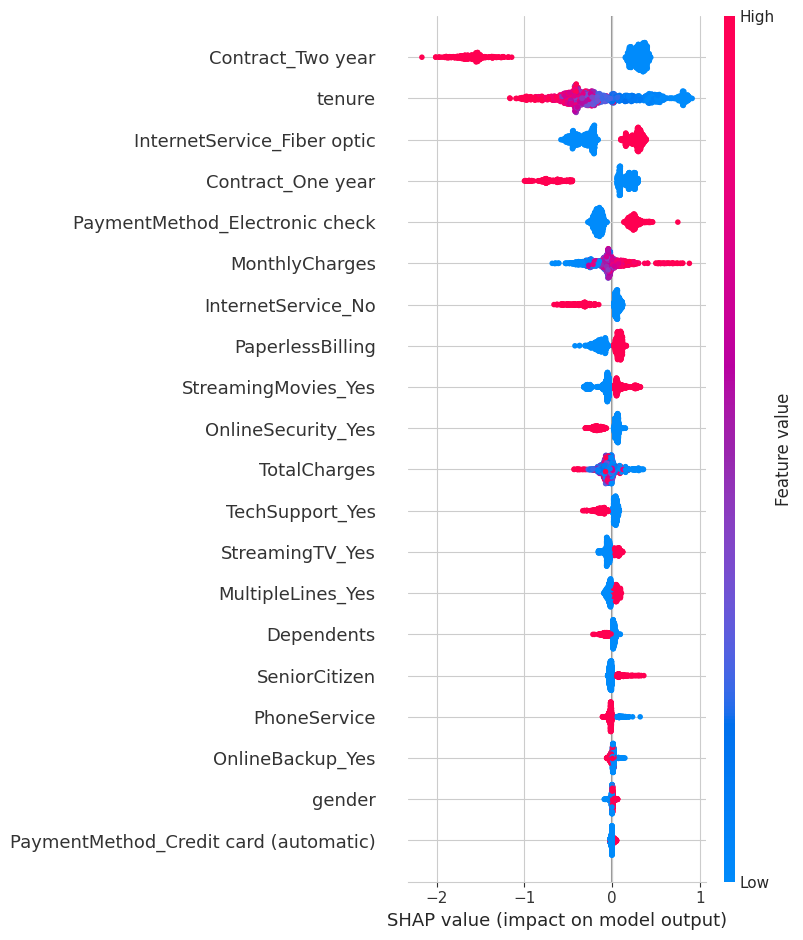

In [26]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

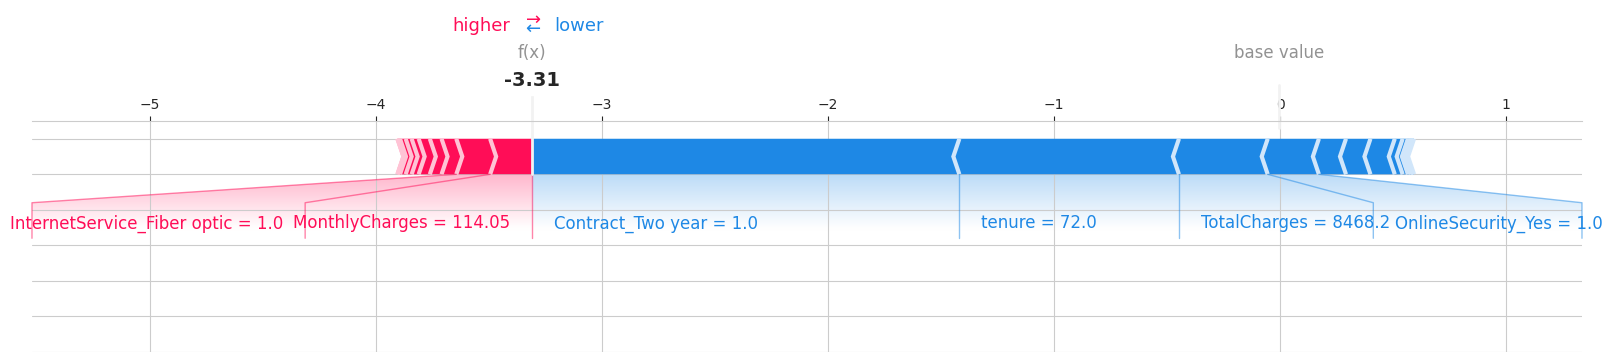

In [27]:
idx = 0
shap.force_plot(explainer.expected_value, shap_values[idx], X_test.iloc[idx], matplotlib=True)